**Convergence Analysis using the Rᵦ Diagnostic for the Random Walk Metropolis Algorithm**

In this part, we evaluate whether the Random Walk Metropolis algorithm has stabilised and is producing reliable results by using the Rᵦ convergence diagnostic. The algorithm is run multiple times using different starting values to produce several chains. If the algorithm has properly converged, these chains should produce similar behaviour even though they begin at different points. The Rᵦ statistic measures how consistent the chains are with each other, where values close to one indicate good convergence. We then analyse how changes in the proposal step size affect the convergence behaviour of the algorithm.

**Importing Libraries**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

**Target Log Density**

In [ ]:
def log_f(x):
    return -np.abs(x) - np.log(2)

**Function to generate one chain**

In [ ]:
def metropolis_chain(N, s, x0):

    x = np.zeros(N)
    x[0] = x0

    for i in range(1, N):

        x_star = np.random.normal(x[i-1], s)

        log_r = log_f(x_star) - log_f(x[i-1])

        u = np.random.uniform(0,1)

        if np.log(u) < log_r:
            x[i] = x_star
        else:
            x[i] = x[i-1]

    return x


**Parameters**

In [ ]:
N = 2000
J = 4
s = 0.001

**Initial Values**

In [ ]:
initial_values = [-5, 0, 5, 10]


**Generate Chains**

In [ ]:
chains = []

for x0 in initial_values:
    chain = metropolis_chain(N, s, x0)
    chains.append(chain)



chains = np.array(chains)

**Comput Mj and Vj**

In [ ]:
Mj = np.mean(chains, axis=1)

Vj = np.var(chains, axis=1)

**Computing W, M, B and Rb**

In [ ]:
# compute W
W = np.mean(Vj)


# compute overall mean M
M = np.mean(Mj)


# compute B
B = np.mean((Mj - M)**2)


# compute Rb
Rb = np.sqrt((B + W) / W)


print("Rb value:", Rb)


**Choosing a different s value and plotting against Rb**

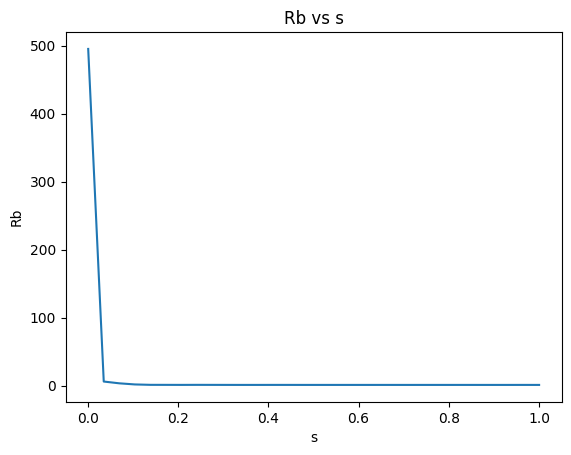

In [ ]:
s_values = np.linspace(0.001, 1, 30)

Rb_values = []

for s in s_values:

    chains = []

    for x0 in initial_values:
        chain = metropolis_chain(N, s, x0)
        chains.append(chain)

    chains = np.array(chains)

    Mj = np.mean(chains, axis=1)

    Vj = np.var(chains, axis=1)

    W = np.mean(Vj)

    M = np.mean(Mj)

    B = np.mean((Mj - M)**2)

    Rb = np.sqrt((B + W) / W)

    Rb_values.append(Rb)



plt.plot(s_values, Rb_values)

plt.xlabel("s")
plt.ylabel("Rb")

plt.title("Rb vs s")

plt.show()